### Final Model Evaluation and Feature Ablation Analysis of  of the gait-based person identification model, including exhaustive trial-grouped validation, performance distributions, feature ablation experiments, and robustness analysis.


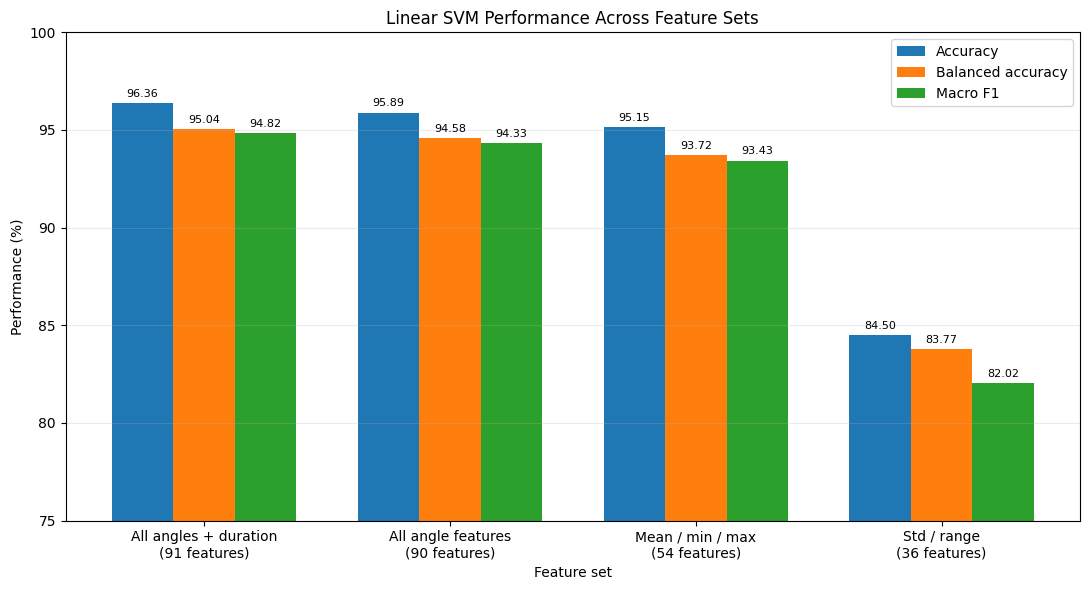

,Feature set,Accuracy,Balanced accuracy,Macro F1
0,All angles + duration\n(91 features),96.36,95.04,94.82
1,All angle features\n(90 features),95.89,94.58,94.33
2,Mean / min / max\n(54 features),95.15,93.72,93.43
3,Std / range\n(36 features),84.50,83.77,82.02


In [22]:
# FINAL FIGURE 1 — Feature-set ablation comparison

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

feature_comparison = pd.DataFrame({
    "Feature set": [
        "All angles + duration\n(91 features)",
        "All angle features\n(90 features)",
        "Mean / min / max\n(54 features)",
        "Std / range\n(36 features)"
    ],
    "Accuracy": [96.36, 95.89, 95.15, 84.50],
    "Balanced accuracy": [95.04, 94.58, 93.72, 83.77],
    "Macro F1": [94.82, 94.33, 93.43, 82.02]
})

x = np.arange(len(feature_comparison))
width = 0.25

fig, ax = plt.subplots(figsize=(11, 6))

b1 = ax.bar(
    x - width,
    feature_comparison["Accuracy"],
    width,
    label="Accuracy"
)

b2 = ax.bar(
    x,
    feature_comparison["Balanced accuracy"],
    width,
    label="Balanced accuracy"
)

b3 = ax.bar(
    x + width,
    feature_comparison["Macro F1"],
    width,
    label="Macro F1"
)

ax.set_ylabel("Performance (%)")
ax.set_xlabel("Feature set")
ax.set_title("Linear SVM Performance Across Feature Sets")

ax.set_xticks(x)
ax.set_xticklabels(feature_comparison["Feature set"])

# Keep enough range to show the real differences
ax.set_ylim(75, 100)

ax.legend()

ax.bar_label(b1, fmt="%.2f", padding=3, fontsize=8)
ax.bar_label(b2, fmt="%.2f", padding=3, fontsize=8)
ax.bar_label(b3, fmt="%.2f", padding=3, fontsize=8)

ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

display(feature_comparison)

In [23]:
# CELL 2 — Load exhaustive evaluation results

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

exhaustive_results_df = pd.read_csv(
    "exhaustive_svm_results.csv"
)

print("Loaded exhaustive results.")
print("Number of trial-holdout combinations:", len(exhaustive_results_df))

display(exhaustive_results_df.head())

print("\nPerformance summary:")
display(
    exhaustive_results_df[
        ["accuracy", "balanced_accuracy", "macro_f1"]
    ].describe().round(4)
)

Loaded exhaustive results.
Number of trial-holdout combinations: 1440


,split_id,accuracy,balanced_accuracy,macro_f1,test_cycles
0,1,0.977528,0.960000,0.963376,89
1,2,0.971429,0.960000,0.968022,70
2,3,0.968085,0.955455,0.951553,94
3,4,0.967391,0.955238,0.952308,92
4,5,0.963964,0.950476,0.956025,111



Performance summary:


,accuracy,balanced_accuracy,macro_f1
count,1440.0000,1440.0000,1440.0000
mean,0.9636,0.9504,0.9482
std,0.0218,0.0316,0.0322
min,0.8500,0.7939,0.7884
25%,0.9514,0.9330,0.9313
50%,0.9663,0.9511,0.9536
75%,0.9781,0.9730,0.9699
max,1.0000,1.0000,1.0000


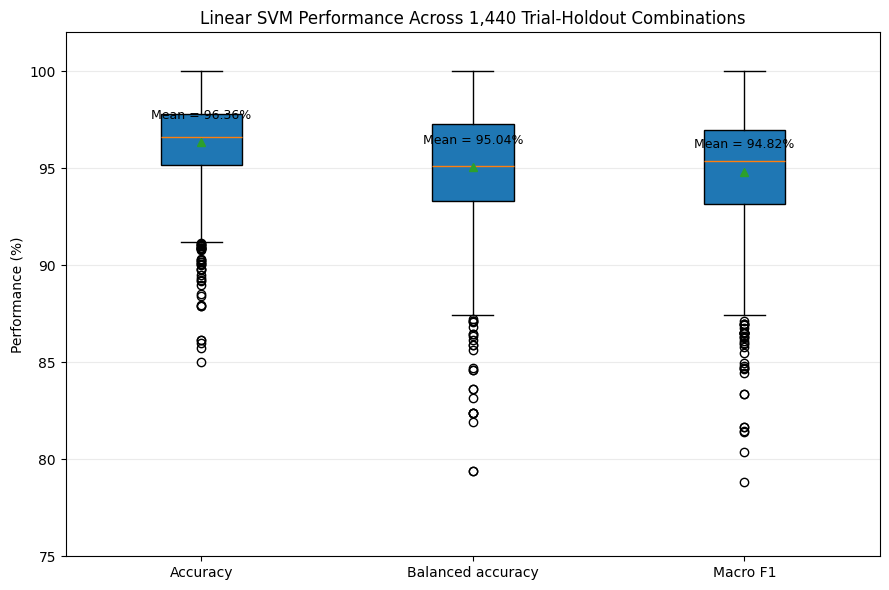

In [24]:
# CELL 3 — Performance distribution across all exhaustive splits

metrics_to_plot = [
    ("accuracy", "Accuracy"),
    ("balanced_accuracy", "Balanced accuracy"),
    ("macro_f1", "Macro F1")
]

data = [
    exhaustive_results_df[col].values * 100
    for col, _ in metrics_to_plot
]

labels = [label for _, label in metrics_to_plot]

fig, ax = plt.subplots(figsize=(9, 6))

ax.boxplot(
    data,
    tick_labels=labels,
    showmeans=True,
    patch_artist=True
)

ax.set_ylabel("Performance (%)")
ax.set_title(
    "Linear SVM Performance Across 1,440 "
    "Trial-Holdout Combinations"
)

ax.set_ylim(75, 102)
ax.grid(axis="y", alpha=0.25)

for i, (col, _) in enumerate(metrics_to_plot, start=1):

    mean_value = exhaustive_results_df[col].mean() * 100

    ax.text(
        i,
        mean_value + 1.2,
        f"Mean = {mean_value:.2f}%",
        ha="center",
        fontsize=9
    )

plt.tight_layout()
plt.show()

In [25]:
# CELL 5 — Performance loss relative to full 91-feature model

baseline_acc = feature_comparison.loc[0, "Accuracy"]
baseline_bal = feature_comparison.loc[0, "Balanced accuracy"]
baseline_f1 = feature_comparison.loc[0, "Macro F1"]

ablation_loss = feature_comparison.copy()

ablation_loss["Accuracy change"] = (
    ablation_loss["Accuracy"] - baseline_acc
)

ablation_loss["Balanced accuracy change"] = (
    ablation_loss["Balanced accuracy"] - baseline_bal
)

ablation_loss["Macro F1 change"] = (
    ablation_loss["Macro F1"] - baseline_f1
)

display(
    ablation_loss.round(2)
)

,Feature set,Accuracy,Balanced accuracy,Macro F1,Accuracy change,Balanced accuracy change,Macro F1 change
0,All angles + duration\n(91 features),96.36,95.04,94.82,0.00,0.00,0.00
1,All angle features\n(90 features),95.89,94.58,94.33,-0.47,-0.46,-0.49
2,Mean / min / max\n(54 features),95.15,93.72,93.43,-1.21,-1.32,-1.39
3,Std / range\n(36 features),84.50,83.77,82.02,-11.86,-11.27,-12.80


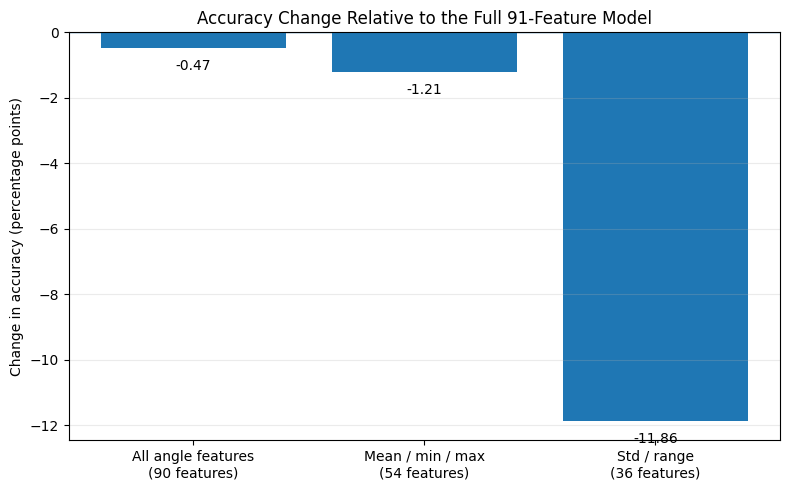

In [26]:
# CELL 6 — Accuracy loss relative to full model

loss_plot = ablation_loss.iloc[1:].copy()

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    loss_plot["Feature set"],
    loss_plot["Accuracy change"]
)

ax.axhline(0, linewidth=1)

ax.set_ylabel("Change in accuracy (percentage points)")
ax.set_title(
    "Accuracy Change Relative to the Full 91-Feature Model"
)

ax.grid(axis="y", alpha=0.25)

for bar, value in zip(bars, loss_plot["Accuracy change"]):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        value - 0.35,
        f"{value:.2f}",
        ha="center",
        va="top"
    )

plt.tight_layout()
plt.show()

In [27]:
# CELL 7 — Final exhaustive evaluation statistics

final_exhaustive_summary = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Balanced accuracy",
        "Macro F1"
    ],

    "Mean (%)": [
        exhaustive_results_df["accuracy"].mean() * 100,
        exhaustive_results_df["balanced_accuracy"].mean() * 100,
        exhaustive_results_df["macro_f1"].mean() * 100
    ],

    "Std (%)": [
        exhaustive_results_df["accuracy"].std() * 100,
        exhaustive_results_df["balanced_accuracy"].std() * 100,
        exhaustive_results_df["macro_f1"].std() * 100
    ],

    "Minimum (%)": [
        exhaustive_results_df["accuracy"].min() * 100,
        exhaustive_results_df["balanced_accuracy"].min() * 100,
        exhaustive_results_df["macro_f1"].min() * 100
    ],

    "Maximum (%)": [
        exhaustive_results_df["accuracy"].max() * 100,
        exhaustive_results_df["balanced_accuracy"].max() * 100,
        exhaustive_results_df["macro_f1"].max() * 100
    ]
})

display(
    final_exhaustive_summary.round(2)
)

,Metric,Mean (%),Std (%),Minimum (%),Maximum (%)
0,Accuracy,96.36,2.18,85.00,100.0
1,Balanced accuracy,95.04,3.16,79.39,100.0
2,Macro F1,94.82,3.22,78.84,100.0


In [28]:
# CELL 8 — Save final result tables

feature_comparison.to_csv(
    "final_feature_comparison.csv",
    index=False
)

ablation_loss.to_csv(
    "final_feature_ablation_loss.csv",
    index=False
)

final_exhaustive_summary.to_csv(
    "final_exhaustive_summary.csv",
    index=False
)

print("Final result tables saved successfully.")

Final result tables saved successfully.


In [29]:
# CELL 9 — Load Model B (PCA + Linear SVM) results

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pca_results_df = pd.read_csv(
    "pca_svm_exhaustive_results.csv"
)

pca_trial_stability = pd.read_csv(
    "pca_svm_trial_stability.csv"
)

print("Model B results loaded successfully.")
print("Exhaustive PCA splits:", len(pca_results_df))
print("Trials:", len(pca_trial_stability))

display(pca_results_df.head())

Model B results loaded successfully.
Exhaustive PCA splits: 1440
Trials: 22


,split,accuracy,balanced_accuracy,macro_f1,n_components,explained_variance
0,1,0.977528,0.960000,0.963376,26,0.954111
1,2,0.971429,0.960000,0.968022,26,0.951004
2,3,0.978723,0.960000,0.970653,26,0.951103
3,4,0.978261,0.960000,0.963376,26,0.953871
4,5,0.954955,0.945348,0.944772,26,0.954619


In [30]:
# CELL 10 — Main Model A vs Model B findings

# Model A results
model_a_dimensions = 91
model_a_accuracy = 96.36
model_a_balanced_accuracy = 95.04
model_a_macro_f1 = 94.82

# Model B results — calculated from saved PCA experiments
model_b_dimensions = pca_results_df["n_components"].mean()

model_b_accuracy = (
    pca_results_df["accuracy"].mean() * 100
)

model_b_balanced_accuracy = (
    pca_results_df["balanced_accuracy"].mean() * 100
)

model_b_macro_f1 = (
    pca_results_df["macro_f1"].mean() * 100
)

variance_retained = (
    pca_results_df["explained_variance"].mean() * 100
)

dimension_reduction = (
    1 - model_b_dimensions / model_a_dimensions
) * 100

accuracy_change = (
    model_b_accuracy - model_a_accuracy
)

print("=" * 65)
print("DIMENSIONALITY REDUCTION — MAIN FINDINGS")
print("=" * 65)

print(f"""
WITHOUT DIMENSIONALITY REDUCTION
Original features       : {model_a_dimensions}
Mean accuracy           : {model_a_accuracy:.2f}%
Balanced accuracy       : {model_a_balanced_accuracy:.2f}%
Macro F1                : {model_a_macro_f1:.2f}%

WITH PCA DIMENSIONALITY REDUCTION
Mean PCA components     : {model_b_dimensions:.2f}
PCA component range     : {pca_results_df["n_components"].min()}–{pca_results_df["n_components"].max()}
Dimension reduction     : {dimension_reduction:.2f}%
Variance retained       : {variance_retained:.2f}%

Mean accuracy           : {model_b_accuracy:.2f}%
Balanced accuracy       : {model_b_balanced_accuracy:.2f}%
Macro F1                : {model_b_macro_f1:.2f}%

Accuracy change         : {accuracy_change:.2f} percentage points
""")

DIMENSIONALITY REDUCTION — MAIN FINDINGS

WITHOUT DIMENSIONALITY REDUCTION
Original features       : 91
Mean accuracy           : 96.36%
Balanced accuracy       : 95.04%
Macro F1                : 94.82%

WITH PCA DIMENSIONALITY REDUCTION
Mean PCA components     : 26.17
PCA component range     : 25–28
Dimension reduction     : 71.24%
Variance retained       : 95.23%

Mean accuracy           : 95.62%
Balanced accuracy       : 93.98%
Macro F1                : 93.81%

Accuracy change         : -0.74 percentage points



In [31]:
# CELL 11 — Final comparison table

model_comparison = pd.DataFrame({
    "Model": [
        "Without dimensionality reduction",
        "PCA dimensionality reduction"
    ],

    "Mean dimensions": [
        model_a_dimensions,
        model_b_dimensions
    ],

    "Dimension reduction (%)": [
        0.00,
        dimension_reduction
    ],

    "Variance retained (%)": [
        100.00,
        variance_retained
    ],

    "Accuracy (%)": [
        model_a_accuracy,
        model_b_accuracy
    ],

    "Balanced accuracy (%)": [
        model_a_balanced_accuracy,
        model_b_balanced_accuracy
    ],

    "Macro F1 (%)": [
        model_a_macro_f1,
        model_b_macro_f1
    ]
})

display(
    model_comparison.round(2)
)

,Model,Mean dimensions,Dimension reduction (%),Variance retained (%),Accuracy (%),Balanced accuracy (%),Macro F1 (%)
0,Without dimensionality reduction,91.00,0.00,100.00,96.36,95.04,94.82
1,PCA dimensionality reduction,26.17,71.24,95.23,95.62,93.98,93.81


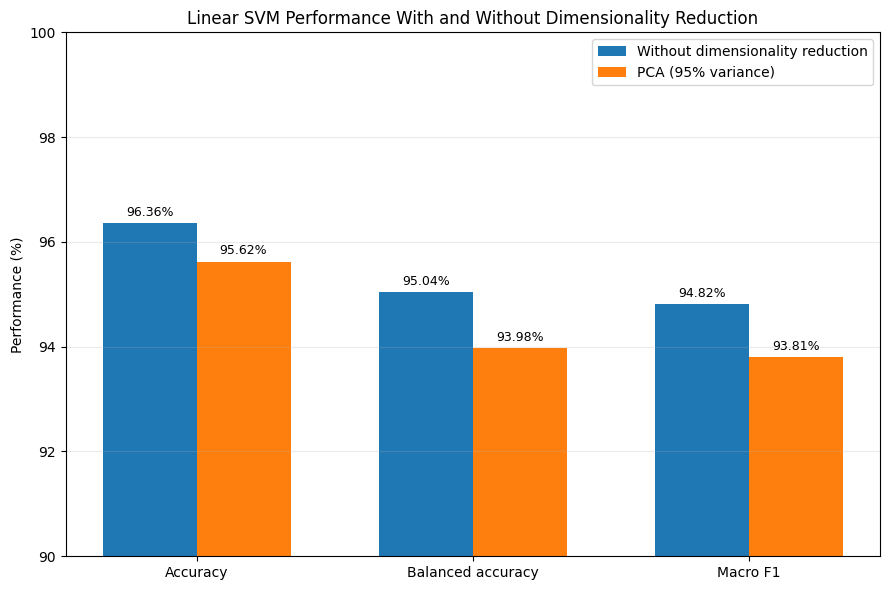

In [32]:
# CELL 12 — Performance with and without dimensionality reduction

metrics = [
    "Accuracy",
    "Balanced accuracy",
    "Macro F1"
]

without_pca = [
    model_a_accuracy,
    model_a_balanced_accuracy,
    model_a_macro_f1
]

with_pca = [
    model_b_accuracy,
    model_b_balanced_accuracy,
    model_b_macro_f1
]

x = np.arange(len(metrics))
width = 0.34

fig, ax = plt.subplots(figsize=(9, 6))

bars1 = ax.bar(
    x - width/2,
    without_pca,
    width,
    label="Without dimensionality reduction"
)

bars2 = ax.bar(
    x + width/2,
    with_pca,
    width,
    label="PCA (95% variance)"
)

ax.set_ylabel("Performance (%)")

ax.set_title(
    "Linear SVM Performance With and Without "
    "Dimensionality Reduction"
)

ax.set_xticks(x)
ax.set_xticklabels(metrics)

ax.set_ylim(90, 100)

ax.legend()
ax.grid(axis="y", alpha=0.25)

ax.bar_label(
    bars1,
    fmt="%.2f%%",
    padding=3,
    fontsize=9
)

ax.bar_label(
    bars2,
    fmt="%.2f%%",
    padding=3,
    fontsize=9
)

plt.tight_layout()
plt.show()

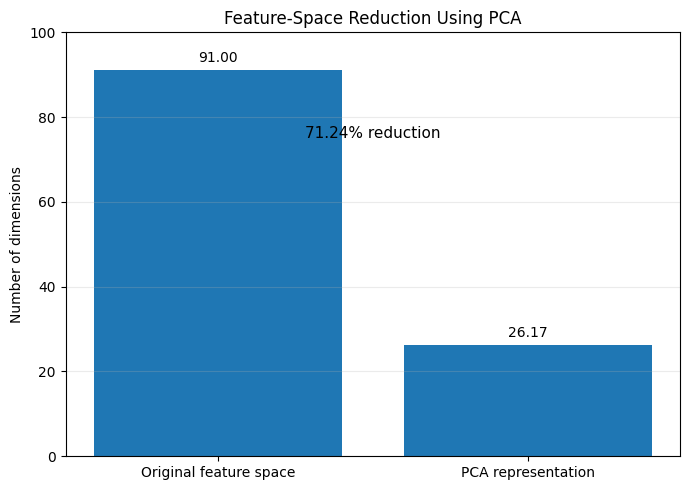

In [33]:
# CELL 13 — Dimensionality reduction achieved by PCA

dimension_df = pd.DataFrame({
    "Representation": [
        "Original feature space",
        "PCA representation"
    ],
    "Dimensions": [
        91,
        model_b_dimensions
    ]
})

fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(
    dimension_df["Representation"],
    dimension_df["Dimensions"]
)

ax.set_ylabel("Number of dimensions")

ax.set_title(
    "Feature-Space Reduction Using PCA"
)

ax.set_ylim(0, 100)
ax.grid(axis="y", alpha=0.25)

for bar, value in zip(
    bars,
    dimension_df["Dimensions"]
):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        value + 2,
        f"{value:.2f}",
        ha="center",
        fontsize=10
    )

ax.text(
    0.5,
    75,
    f"{dimension_reduction:.2f}% reduction",
    ha="center",
    fontsize=11
)

plt.tight_layout()
plt.show()

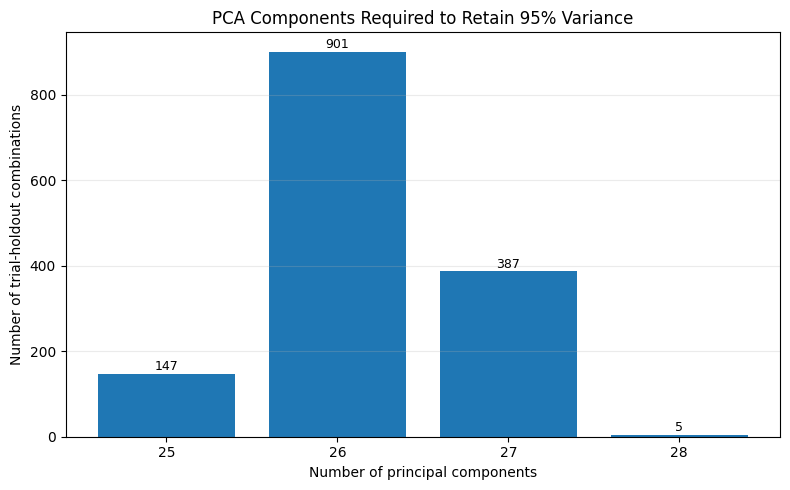

Mean PCA components: 26.17
Range: 25–28
Mean explained variance: 95.23%


In [34]:
# CELL 14 — PCA components needed to retain 95% variance

component_counts = (
    pca_results_df["n_components"]
    .value_counts()
    .sort_index()
)

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    component_counts.index.astype(str),
    component_counts.values
)

ax.set_xlabel(
    "Number of principal components"
)

ax.set_ylabel(
    "Number of trial-holdout combinations"
)

ax.set_title(
    "PCA Components Required to Retain 95% Variance"
)

ax.grid(axis="y", alpha=0.25)

for bar, value in zip(
    bars,
    component_counts.values
):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        value + 8,
        str(value),
        ha="center",
        fontsize=9
    )

plt.tight_layout()
plt.show()

print(
    f"Mean PCA components: "
    f"{model_b_dimensions:.2f}"
)

print(
    f"Range: "
    f"{pca_results_df['n_components'].min()}–"
    f"{pca_results_df['n_components'].max()}"
)

print(
    f"Mean explained variance: "
    f"{variance_retained:.2f}%"
)

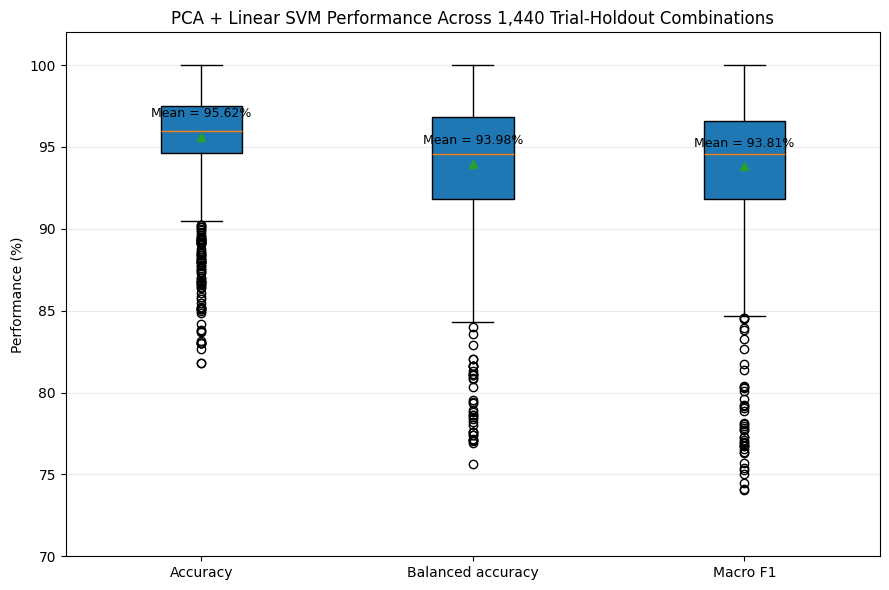

In [35]:
# CELL 15 — PCA performance across all 1,440 holdout combinations

metrics_to_plot = [
    ("accuracy", "Accuracy"),
    ("balanced_accuracy", "Balanced accuracy"),
    ("macro_f1", "Macro F1")
]

data = [
    pca_results_df[col].values * 100
    for col, _ in metrics_to_plot
]

labels = [
    label
    for _, label in metrics_to_plot
]

fig, ax = plt.subplots(figsize=(9, 6))

ax.boxplot(
    data,
    tick_labels=labels,
    showmeans=True,
    patch_artist=True
)

ax.set_ylabel("Performance (%)")

ax.set_title(
    "PCA + Linear SVM Performance Across "
    "1,440 Trial-Holdout Combinations"
)

ax.set_ylim(70, 102)

ax.grid(
    axis="y",
    alpha=0.25
)

for i, (col, _) in enumerate(
    metrics_to_plot,
    start=1
):

    mean_value = (
        pca_results_df[col].mean()
        * 100
    )

    ax.text(
        i,
        mean_value + 1.2,
        f"Mean = {mean_value:.2f}%",
        ha="center",
        fontsize=9
    )

plt.tight_layout()
plt.show()

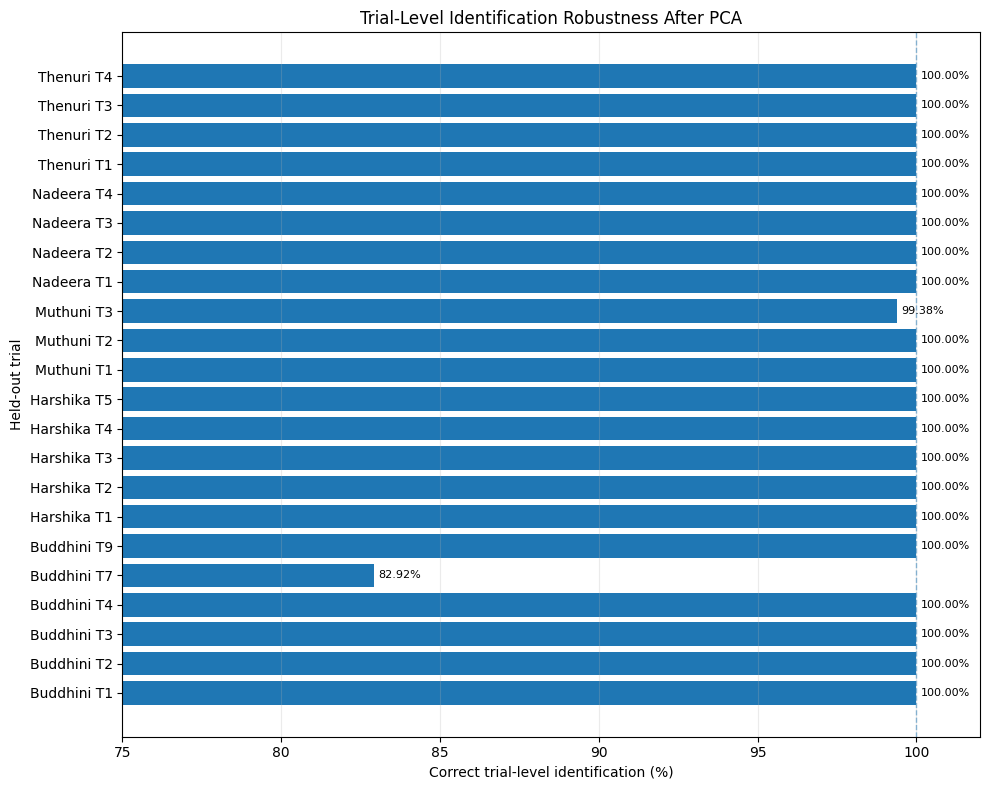

In [36]:
# CELL 16 — Trial-level robustness after PCA

trial_plot = pca_trial_stability.copy()

trial_plot["Trial"] = (
    trial_plot["person"].astype(str)
    + " T"
    + trial_plot["trial"].astype(str)
)

trial_plot = trial_plot.sort_values(
    ["person", "trial"]
)

fig, ax = plt.subplots(
    figsize=(10, 8)
)

bars = ax.barh(
    trial_plot["Trial"],
    trial_plot["correct_pct"]
)

ax.set_xlabel(
    "Correct trial-level identification (%)"
)

ax.set_ylabel(
    "Held-out trial"
)

ax.set_title(
    "Trial-Level Identification Robustness "
    "After PCA"
)

ax.set_xlim(75, 102)

ax.axvline(
    100,
    linestyle="--",
    linewidth=1,
    alpha=0.5
)

ax.grid(
    axis="x",
    alpha=0.25
)

for bar, value in zip(
    bars,
    trial_plot["correct_pct"]
):

    ax.text(
        value + 0.15,
        bar.get_y()
        + bar.get_height()/2,

        f"{value:.2f}%",

        va="center",
        fontsize=8
    )

plt.tight_layout()
plt.show()

In [38]:
# CELL 18 — Save final PCA results

model_comparison.to_csv(
    "final_modelA_vs_modelB_comparison.csv",
    index=False
)

pca_trial_stability.to_csv(
    "final_pca_trial_stability.csv",
    index=False
)

print("Final PCA comparison results saved.")

Final PCA comparison results saved.


In [37]:
# CELL 17 — Important findings

perfect_trials = (
    pca_trial_stability["correct_pct"] == 100
).sum()

total_trials = len(
    pca_trial_stability
)

print("=" * 72)
print("IMPORTANT FINDINGS — DIMENSIONALITY REDUCTION")
print("=" * 72)

print(
    f"""
1. WITHOUT DIMENSIONALITY REDUCTION

   The 91-feature Linear SVM achieved:
   • Mean accuracy          = {model_a_accuracy:.2f}%
   • Balanced accuracy      = {model_a_balanced_accuracy:.2f}%
   • Macro F1               = {model_a_macro_f1:.2f}%


2. WITH PCA DIMENSIONALITY REDUCTION

   PCA reduced the original 91-dimensional representation
   to an average of {model_b_dimensions:.2f} principal components.

   • PCA component range    = {pca_results_df["n_components"].min()}–{pca_results_df["n_components"].max()}
   • Dimensionality reduced = {dimension_reduction:.2f}%
   • Variance retained      = {variance_retained:.2f}%


3. PCA + LINEAR SVM PERFORMANCE

   • Mean accuracy          = {model_b_accuracy:.2f}%
   • Balanced accuracy      = {model_b_balanced_accuracy:.2f}%
   • Macro F1               = {model_b_macro_f1:.2f}%


4. EFFECT OF DIMENSIONALITY REDUCTION

   Accuracy changed from {model_a_accuracy:.2f}% to
   {model_b_accuracy:.2f}%, a difference of
   {accuracy_change:.2f} percentage points.

   Therefore, PCA removed approximately {dimension_reduction:.2f}%
   of the original dimensions while preserving most of the
   classification performance.


5. TRIAL-LEVEL ROBUSTNESS

   {perfect_trials}/{total_trials} held-out trials were correctly
   identified in 100% of their training configurations.

   Buddhini Trial 7 was the least stable PCA trial.
"""
)

IMPORTANT FINDINGS — DIMENSIONALITY REDUCTION

1. WITHOUT DIMENSIONALITY REDUCTION

   The 91-feature Linear SVM achieved:
   • Mean accuracy          = 96.36%
   • Balanced accuracy      = 95.04%
   • Macro F1               = 94.82%


2. WITH PCA DIMENSIONALITY REDUCTION

   PCA reduced the original 91-dimensional representation
   to an average of 26.17 principal components.

   • PCA component range    = 25–28
   • Dimensionality reduced = 71.24%
   • Variance retained      = 95.23%


3. PCA + LINEAR SVM PERFORMANCE

   • Mean accuracy          = 95.62%
   • Balanced accuracy      = 93.98%
   • Macro F1               = 93.81%


4. EFFECT OF DIMENSIONALITY REDUCTION

   Accuracy changed from 96.36% to
   95.62%, a difference of
   -0.74 percentage points.

   Therefore, PCA removed approximately 71.24%
   of the original dimensions while preserving most of the
   classification performance.


5. TRIAL-LEVEL ROBUSTNESS

   20/22 held-out trials were correctly
   identified in 100% of 

Without dimensionality reduction, the 91-feature Linear SVM achieved 96.36% mean accuracy.

 With PCA, the representation was reduced to an average of 26.17 components (71.24% fewer dimensions) while retaining 95.23% of variance, and the Linear SVM maintained 95.62% mean accuracy, a reduction of only 0.74 percentage points.